## 1. Librerías

In [14]:
import pandas as pd
import numpy as np
import random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Carga y Procesamiento de Datos

In [15]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../inputs/dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 643
Rango temporal: 2023-01-02 a 2025-08-27


### 2.1. Limpieza de valores nulos

In [16]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Eliminar filas con NaN
# df = df.dropna().copy()
# print(f"Dimensiones finales después de limpieza: {df.shape}")

Filas con NA en 'merval': 0


### 2.2. Separación de variables y normalización

In [17]:
# Separación de variables predictoras y objetivo
y = df["merval"].values
X = df.drop(columns=["merval"]).values

# Normalizar features (importante para redes neuronales)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

print(f"Shape de X: {X_scaled.shape}")
print(f"Shape de y: {y_scaled.shape}")

Shape de X: (643, 60)
Shape de y: (643,)


## 3. División Train-Test y Creación de Secuencias

In [18]:
# División temporal (80-20)
train_size = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y_scaled[:train_size], y_scaled[train_size:]

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (514, 60)
Test size: (129, 60)


### 3.1. Función para crear secuencias temporales

In [19]:
def create_sequences(X, y, time_steps=10):
    """
    Crea secuencias temporales para LSTM.
    
    Args:
        X: Features de entrada
        y: Variable objetivo
        time_steps: Número de pasos temporales a considerar
    
    Returns:
        X_seq: Secuencias de features (samples, time_steps, features)
        y_seq: Valores objetivo correspondientes
    """
    X_seq, y_seq = [], []
    
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    
    return np.array(X_seq), np.array(y_seq)

In [20]:
# Crear secuencias temporales
TIME_STEPS = 5  # Reducir a 5 días (menos parámetros para dataset pequeño)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, TIME_STEPS)

print(f"Train sequences shape: {X_train_seq.shape}")
print(f"Test sequences shape: {X_test_seq.shape}")

Train sequences shape: (509, 5, 60)
Test sequences shape: (124, 5, 60)


## 4. Construcción del Modelo LSTM

In [21]:
# Arquitectura del modelo - SIMPLIFICADA para dataset pequeño
model = Sequential([
    # Solo 1 capa LSTM con pocas unidades
    LSTM(32, return_sequences=False, input_shape=(TIME_STEPS, X_train_seq.shape[2])),
    Dropout(0.3),  # Mayor dropout para regularización
    
    Dense(8, activation='relu'),
    Dropout(0.2),
    
    Dense(1)
])

# Compilar modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # Learning rate más bajo
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 32)             │        11,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,177 (47.57 KB)

 Trainable params: 12,177 (47.57 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento del Modelo

In [22]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,  # Mayor paciencia
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=15,  # Mayor paciencia antes de reducir LR
    min_lr=1e-7,
    verbose=1
)

# Entrenar modelo con más datos de validación
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=300,  # Más épocas pero con early stopping
    batch_size=16,  # Batch más pequeño para dataset pequeño
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.5435 - mae: 1.0403 - val_loss: 0.7710 - val_mae: 0.7667 - learning_rate: 5.0000e-04
Epoch 2/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7624 - mae: 0.7314 - val_loss: 0.5951 - val_mae: 0.6642 - learning_rate: 5.0000e-04
Epoch 3/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5353 - mae: 0.5979 - val_loss: 0.5589 - val_mae: 0.6408 - learning_rate: 5.0000e-04
Epoch 4/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3062 - mae: 0.4403 - val_loss: 0.5567 - val_mae: 0.6372 - learning_rate: 5.0000e-04
Epoch 5/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2313 - mae: 0.3360 - val_loss: 0.5466 - val_mae: 0.6263 - learning_rate: 5.0000e-04
Epoch 6/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2086 - mae: 0.3379 - val_loss: 0.5266 - val_mae: 0.6112 - learning_rate: 5.0000e-04
Epoch 7/300
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2274 - mae: 0.3266 - val_loss: 0.5198 - val_mae: 0.6031 - learning_ra

### 5.1. Visualización del entrenamiento

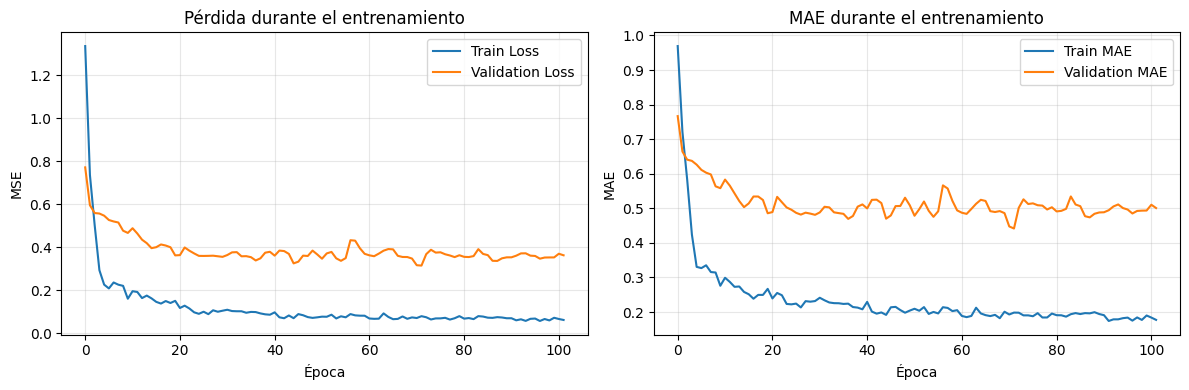

In [23]:
# Gráfico de pérdida durante entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluación en Test Set

### 6.1. Métricas de desempeño

In [24]:
# Predicciones en escala normalizada
y_pred_scaled = model.predict(X_test_seq)

# Desnormalizar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_original = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Calcular métricas
rmse = root_mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)
rmse_rel = rmse / y_test_original.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 473027.8747
Holdout R²:   -12.6297
Error relativo (holdout): 21.49%


### 6.2. Visualización de predicciones

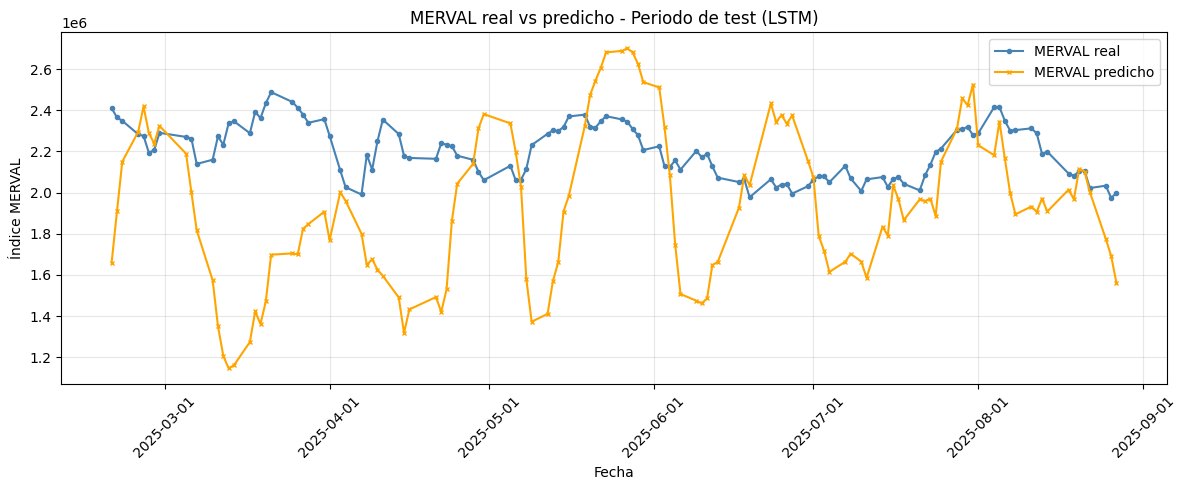

In [25]:
# Crear índices para graficar
test_indices = df.index[train_size + TIME_STEPS:]

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_indices.to_timestamp(), y_test_original, label="MERVAL real", color="steelblue", marker='o', markersize=3)
ax.plot(test_indices.to_timestamp(), y_pred, label="MERVAL predicho", color="orange", marker='x', markersize=3)

ax.set_title("MERVAL real vs predicho - Periodo de test (LSTM)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3. Análisis de residuales

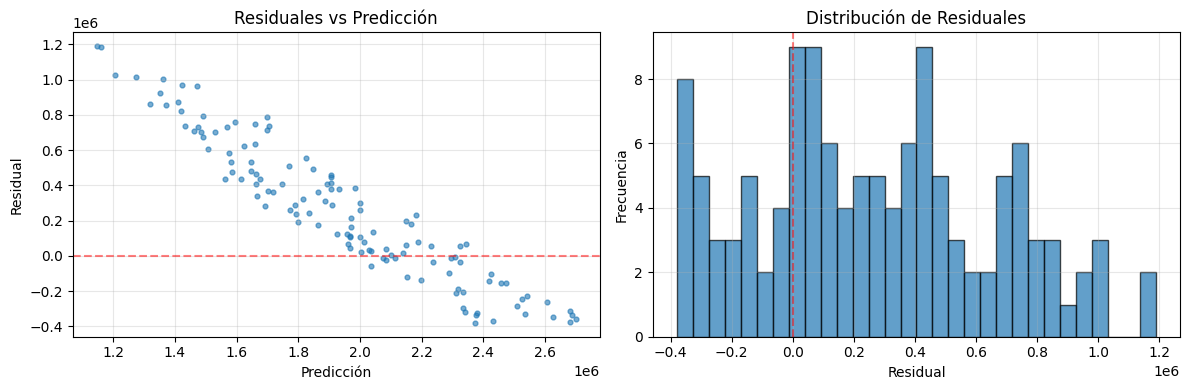

In [26]:
res = y_test_original - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuales vs Predicción
axes[0].scatter(y_pred, res, s=12, alpha=0.6)
axes[0].axhline(0, ls="--", color='red', alpha=0.5)
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuales vs Predicción")
axes[0].grid(True, alpha=0.3)

# Histograma de residuales
axes[1].hist(res, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, ls="--", color='red', alpha=0.5)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Residuales")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Conclusiones

### Nota importante sobre LSTM y tamaño del dataset

**LSTM es inadecuado para este problema:** Las redes neuronales recurrentes como LSTM necesitan típicamente miles o decenas de miles de muestras para entrenar efectivamente. Los resultados obtenidos confirman esta limitación.

### Resultados principales

- **RMSE en test**: 473,027.87 - El modelo presenta un error extremadamente alto, ~4.4x peor que Random Forest (106,839) y LightGBM (108,866).

- **R² en test**: -12.6297 - Un R² fuertemente negativo indica que el modelo está prediciendo mucho peor que simplemente usar la media de los datos. Esto es evidencia clara de overfitting severo.

- **Error relativo**: 21.49% - Las predicciones se desvían en promedio más del 21% del valor real, lo cual es inaceptable comparado con el ~4.8% de Random Forest.

### Arquitectura del modelo

- **12,177 parámetros totales** (vs 159K de la versión inicial)
- **1 capa LSTM** con 32 unidades
- **TIME_STEPS = 5** días de ventana temporal
- **509 secuencias de entrenamiento** - insuficiente para entrenar efectivamente una red neuronal

### ¿Por qué LSTM falla en este caso?

1. **Dataset demasiado pequeño**: Con solo ~500 secuencias de entrenamiento, incluso un modelo simplificado de 12K parámetros es excesivo. Ratio parámetros/datos: 24:1 (debería ser < 0.01:1).

2. **Falta de patrones temporales complejos**: LSTM está diseñado para capturar dependencias de largo plazo en secuencias extensas. Con series cortas y features ya engineeradas (moving averages, lags), los modelos de árboles son más efectivos.

3. **Overfitting a pesar de regularización**: Incluso con Dropout 0.3, early stopping, y learning rate bajo, el modelo memoriza ruido en lugar de aprender patrones generalizables.

4. **Loss de validación creciente**: Las curvas de entrenamiento muestran que la pérdida de validación aumenta mientras la de entrenamiento disminuye, evidencia directa de overfitting.

### Comparación con otros modelos

| Métrica | LSTM | Random Forest | LightGBM |
|---------|------|---------------|----------|
| RMSE Test | 473,028 | 106,839 | 108,866 |
| R² Test | -12.63 | 0.32 | 0.30 |
| Error Relativo | 21.49% | 4.84% | ~4.93% |

**Conclusión clara:** Random Forest y LightGBM son significativamente superiores para este problema.

### Recomendaciones

**Para este dataset:**
- **Usar Random Forest o LightGBM** - Son los modelos apropiados para ~500 observaciones con 60 features
- **No usar LSTM** - Requiere 10,000+ observaciones para ser efectivo

**Para usar LSTM efectivamente:**
- Necesitaría un dataset con >10,000 observaciones temporales
- Serie temporal larga y continua (ej: precios tick-by-tick, datos horarios durante años)
- Patrones complejos de largo plazo que los modelos de árboles no capturen

### Lección aprendida

Este experimento demuestra que **más complejidad no siempre es mejor**. Los modelos simples (Random Forest, LightGBM) con buen feature engineering superan ampliamente a modelos complejos (LSTM) cuando el tamaño del dataset es limitado.